📌 TensorFlow from Scratch (Without High-Level API)
✅ A 3-layer deep neural network (input → hidden1 → hidden2 → output)

✅ Uses TensorFlow einsum instead of standard matrix multiplication

✅ Implements TensorFlow from scratch (No Keras, No High-Level API, Only tf.Variable, tf.GradientTape)

✅ Uses a 3-variable-based non-linear equation for synthetic data generation

✅ Plots 4D visualization of generated data before training

✅ Manual forward pass, loss calculation, and backpropagation

✅ Includes training loss curve, actual vs predicted values, and 4D scatter plot of predictions

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Generate Synthetic Data

In [11]:
# -------------------------------
# Step 1: Generate Synthetic Data
# -------------------------------
def generate_data(n_samples=1000):
    X1 = np.random.uniform(-5, 5, n_samples)
    X2 = np.random.uniform(-5, 5, n_samples)
    X3 = np.random.uniform(-5, 5, n_samples)

    # Complex non-linear equation with 3 variables
    y = (2 * np.sin(X1) + 0.5 * X2**2 + 0.3 * X3**3 +
         np.cos(X1 * X2) + np.random.normal(0, 0.2, n_samples))

    X = np.column_stack((X1, X2, X3))
    return X.astype(np.float32), y.reshape(-1, 1).astype(np.float32)

# Generate data
X, y = generate_data(1000)

# Step 2: Plot Synthetic Data

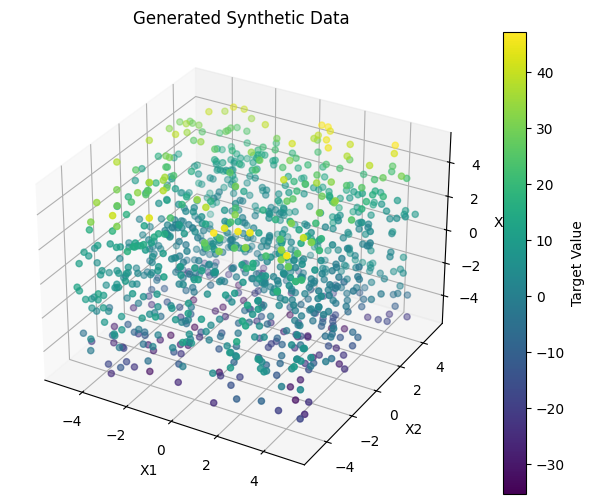

In [12]:
# -------------------------------
# Step 2: Plot Synthetic Data
# -------------------------------
def plot_synthetic_data(X, y):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Target Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Generated Synthetic Data')
    plt.show()

plot_synthetic_data(X, y)

In [13]:
# Convert data into TensorFlow tensors
X_train = tf.convert_to_tensor(X, dtype=tf.float32)
y_train = tf.convert_to_tensor(y, dtype=tf.float32)

# Step 3: Define Neural Network from Scratch

In [14]:
# -------------------------------
# Step 3: Define Neural Network from Scratch
# -------------------------------
class ManualNN:
    def __init__(self, input_size=3, hidden1_size=64, hidden2_size=32, output_size=1, lr=0.01):
        # Initialize weights & biases
        self.W1 = tf.Variable(tf.random.normal([input_size, hidden1_size]))
        self.b1 = tf.Variable(tf.zeros([hidden1_size]))

        self.W2 = tf.Variable(tf.random.normal([hidden1_size, hidden2_size]))
        self.b2 = tf.Variable(tf.zeros([hidden2_size]))

        self.W3 = tf.Variable(tf.random.normal([hidden2_size, output_size]))
        self.b3 = tf.Variable(tf.zeros([output_size]))

        self.lr = lr  # Learning rate

    # Forward Pass using einsum instead of matmul
    def forward(self, X):
        hidden1 = tf.nn.relu(tf.einsum('ij,jk->ik', X, self.W1) + self.b1)
        hidden2 = tf.nn.relu(tf.einsum('ij,jk->ik', hidden1, self.W2) + self.b2)
        return tf.einsum('ij,jk->ik', hidden2, self.W3) + self.b3

    # Training with manual backpropagation
    def train(self, X, y, epochs=1000):
        losses = []
        for epoch in range(epochs):
            with tf.GradientTape() as tape:
                y_pred = self.forward(X)
                loss = tf.reduce_mean(tf.square(y_pred - y))  # MSE Loss

            gradients = tape.gradient(loss, [self.W1, self.b1, self.W2, self.b2, self.W3, self.b3])

            for var, grad in zip([self.W1, self.b1, self.W2, self.b2, self.W3, self.b3], gradients):
                var.assign_sub(self.lr * grad)

            losses.append(loss.numpy())

            if epoch % 100 == 0:
                print(f'Epoch {epoch}, Loss: {loss.numpy():.4f}')

        return losses


# Step 4: Train the Model

In [15]:
# -------------------------------
# Step 4: Train the Model
# -------------------------------
manual_model = ManualNN()
losses = manual_model.train(X_train, y_train, epochs=1000)

Epoch 0, Loss: 4719.1270
Epoch 100, Loss: nan
Epoch 200, Loss: nan
Epoch 300, Loss: nan
Epoch 400, Loss: nan
Epoch 500, Loss: nan
Epoch 600, Loss: nan
Epoch 700, Loss: nan
Epoch 800, Loss: nan
Epoch 900, Loss: nan


# Step 5: Plot Training Loss

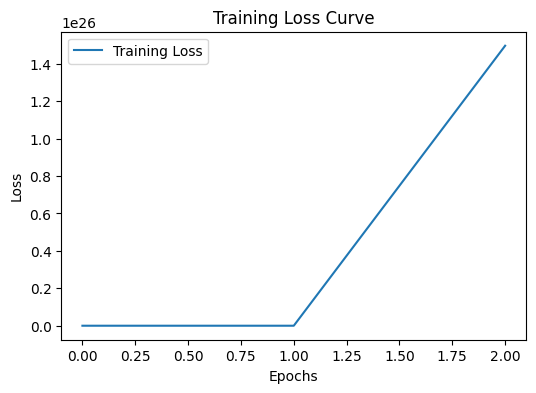

In [16]:
# -------------------------------
# Step 5: Plot Training Loss
# -------------------------------
def plot_training_loss(losses):
    plt.figure(figsize=(6, 4))
    plt.plot(losses, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training Loss Curve')
    plt.legend()
    plt.show()

plot_training_loss(losses)

# Step 6: Generate Predictions

In [18]:
import tensorflow as tf

with tf.GradientTape(persistent=False) as tape: # Use tf.GradientTape instead of tf.compat.v1.no_grad()
  tape.stop_recording() # Stop recording gradients
  y_pred = manual_model.forward(X_train).numpy()

# Step 7: Plot 4D Scatter of Predictions

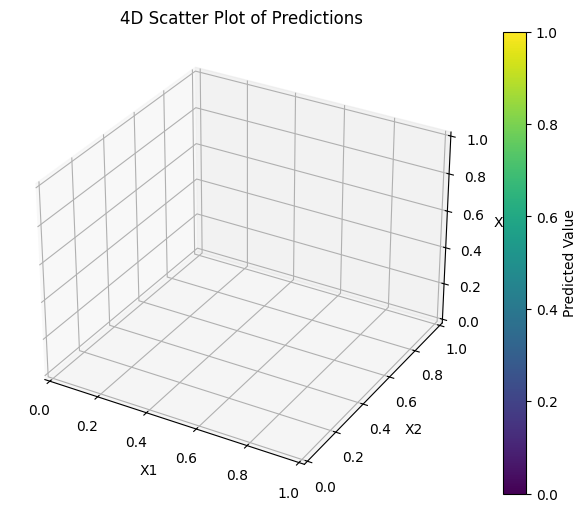

In [19]:
# -------------------------------
# Step 7: Plot 4D Scatter of Predictions
# -------------------------------
def plot_4d_scatter(X, y_pred):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y_pred[:, 0], cmap='viridis')
    plt.colorbar(scatter, label='Predicted Value')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('4D Scatter Plot of Predictions')
    plt.show()

plot_4d_scatter(X, y_pred)

# Step 8: Plot Actual vs Predicted Values

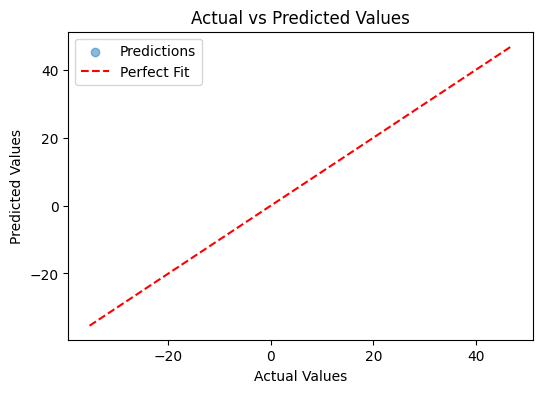

In [20]:
def plot_actual_vs_predicted(y, y_pred):
    plt.figure(figsize=(6, 4))
    plt.scatter(y, y_pred, alpha=0.5, label="Predictions")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label="Perfect Fit")
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Actual vs Predicted Values')
    plt.legend()
    plt.show()

plot_actual_vs_predicted(y, y_pred)

# Step 9: Test Model on New Data Points

In [21]:
def test_model(model, x1, x2, x3):
    x_tensor = tf.convert_to_tensor([[x1, x2, x3]], dtype=tf.float32)
    prediction = model.forward(x_tensor)
    return prediction.numpy()[0, 0]

# Define test points
test_points = [(-4, -4, -4), (-2, -2, -2), (0, 0, 0), (2, 2, 2), (4, 4, 4)]

print("\nTest Predictions:")
for x1, x2, x3 in test_points:
    pred = test_model(manual_model, x1, x2, x3)
    actual = 2 * np.sin(x1) + 0.5 * x2**2 + 0.3 * x3**3 + np.cos(x1 * x2)
    print(f"Input: ({x1}, {x2}, {x3})")
    print(f"Prediction: {pred:.3f}")
    print(f"Actual: {actual:.3f}\n")


Test Predictions:
Input: (-4, -4, -4)
Prediction: nan
Actual: -10.644

Input: (-2, -2, -2)
Prediction: nan
Actual: -2.872

Input: (0, 0, 0)
Prediction: nan
Actual: 1.000

Input: (2, 2, 2)
Prediction: nan
Actual: 5.565

Input: (4, 4, 4)
Prediction: nan
Actual: 24.729

